# **Project Scenario**
In this project, you will be working with transactional data from an online retail store. The dataset contains information about customer purchases, including product details, quantities, prices, and timestamps. Your task is to explore and analyze this dataset to gain insights into the store's sales trends, customer behavior, and popular products.

By conducting exploratory data analysis EDA, you will identify patterns, outliers, and correlations in the data, allowing you to make data-driven decisions and recommendations to optimize the store's operations and improve customer satisfaction.

## **data set**
data set  contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

### **Column descriptions**

**InvoiceNo** Invoice number of the transaction

**StockCode** Unique code of the product

**Description** Description of the product

**Quantity** Quantity of the product in the transaction

**InvoiceDate** Date and time of the transaction

**UnitPrice** Unit price of the product

**CustomerID** Unique identifier of the customer

**Country** Country where the transaction occurred



# Note this requiremnet is only a helpful and not  mandatory to follow and you can build your own way of cleaning and processing , write your colclusion and your insights for each analysis you made also your recommendation

# Requirements
1. Load the dataset - display the first 7 rows
2. Perform data cleaning by handling missing values, if any, and removing any redundant or unnecessary columns.
3. Explore the basic statistics of the dataset.
4. Perform data visualization to gain insights into the dataset. Generate appropriate plots, such
as histograms, scatter plots, or bar plots, to visualize different aspects of the data.
>>1. **Customer Distribution:**
Generate a histogram to showcase the distribution of the number of purchases made by each customer (CustomerID).
Label the x-axis with CustomerIDs and the y-axis with the corresponding counts.
Include appropriate title and axis labels.
>> 2. **Sales Over Time:**
Plot a line chart to depict the trend in total sales quantity over time.
Convert the 'InvoiceDate' column to a datetime format and use it as the x-axis.
Sum the 'Quantity' for each date to represent daily sales.
Add a title and label the x and y-axes accordingly.
>> 3. **Country-wise Sales**:
Create a bar chart to visualize the total sales quantity for each country.
Group the data by 'Country' and sum the 'Quantity' for each.
Label the x-axis with countries and provide a title and axis labels.
>> 4. **Product Price Distribution:**
Construct a histogram to display the distribution of product prices ('UnitPrice').
Use appropriate bins to capture the range of prices effectively.
Label the x-axis with price ranges and the y-axis with frequency.
Add a title and axis labels for clarity.
 >>5. **Top Selling Products:**
Identify and visualize the top N (e.g., 10) best-selling products based on total quantity sold.
Create a bar chart with the product descriptions on the x-axis and total quantity on the y-axis.
Label axes and provide a title.

5. Analyze the sales trends over time. Identify the busiest months and days of the week in terms
of sales.
6. create a bar chart to visualize the total quantity of each product (StockCode) sold in the provided sample dataset? Additionally, label the x-axis with the StockCodes and provide a meaningful title and axis labels for clarity in interpretation.
7. Identify any outliers or anomalies in the dataset and discuss their potential impact on the
analysis.
8. write conclusions and summarize your findings from the exploratory data analysis.

In [2]:
#import needed libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Load the dataset - display the first 7 rows

In [5]:

path="/content/drive/MyDrive/python project/Online_Retail.xlsx"

df=pd.read_excel(path)

df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
df['CustomerID'] = df['CustomerID'].astype(str)

df=df.dropna(subset=["CustomerID"])


/tmp/ipython-input-76-898949626.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
 8   TotalPrice   406829 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 31.0+ MB


### 2. Perform data cleaning by handling missing values, if any, and removing any redundant or unnecessary columns

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [ ]:
df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)


,TotalPrice
CustomerID,
14646.0,279489.02
18102.0,256438.49
17450.0,187482.17
14911.0,132572.62
12415.0,123725.45
...,...
12503.0,-1126.00
17603.0,-1165.30
14213.0,-1192.20


In [ ]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)



,TotalPrice
Country,
United Kingdom,6767873.394
Netherlands,284661.540
EIRE,250285.220
Germany,221698.210
France,196712.840
Australia,137077.270
Switzerland,55739.400
Spain,54774.580
Belgium,40910.960


In [ ]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)


,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53215
JUMBO BAG RED RETROSPOT,45066
ASSORTED COLOUR BIRD ORNAMENT,35314
WHITE HANGING HEART T-LIGHT HOLDER,34147
PACK OF 72 RETROSPOT CAKE CASES,33409
...,...
PINK POODLE HANGING DECORATION,-12
CRUK Commission,-16
ASSORTED TUTTI FRUTTI ROUND BOX,-24


In [ ]:
sales_by_customer = df.groupby('CustomerID')[['Quantity', 'TotalPrice']].sum().reset_index()
sales_by_customer = sales_by_customer.sort_values(by='TotalPrice', ascending=False)
sales_by_customer

,CustomerID,Quantity,TotalPrice
1703,14646.0,196719,279489.02
4233,18102.0,64122,256438.49
3758,17450.0,69029,187482.17
1895,14911.0,77180,132572.62
55,12415.0,77242,123725.45
...,...,...,...
125,12503.0,-1,-1126.00
3870,17603.0,-31,-1165.30
1384,14213.0,-244,-1192.20
2236,15369.0,-1,-1592.49


### 3.Explore the basic statistics of the dataset. (description)

In [ ]:
import plotly.express as px

top_customers = sales_by_customer.head(10)
fig = px.bar(top_customers, x='CustomerID', y='TotalPrice', title='Top 10 Customers by Total Spending')
fig.show()


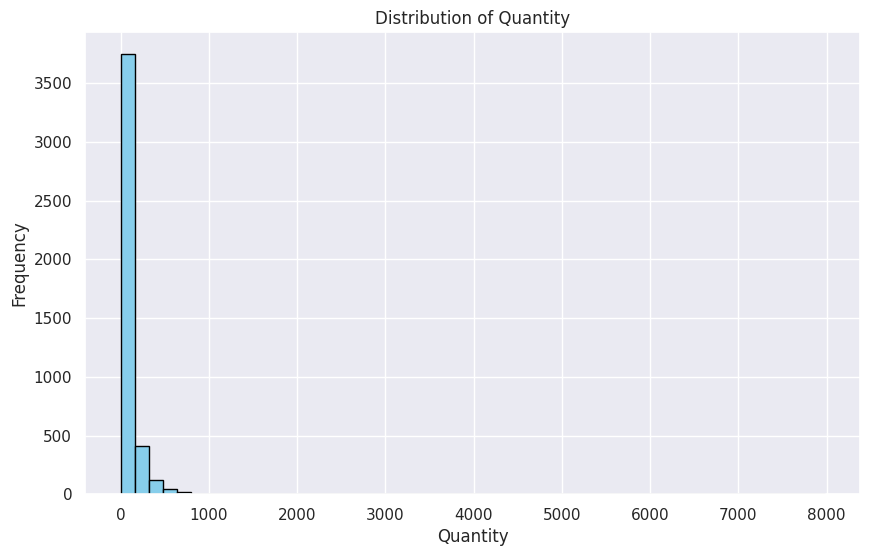

In [ ]:
#Customer Distribution
import matplotlib.pyplot as plt

num_of_purch=df.groupby('CustomerID')['InvoiceNo'].count().sort_values(ascending=False)


plt.figure(figsize=(10,6))
plt.hist(num_of_purch, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



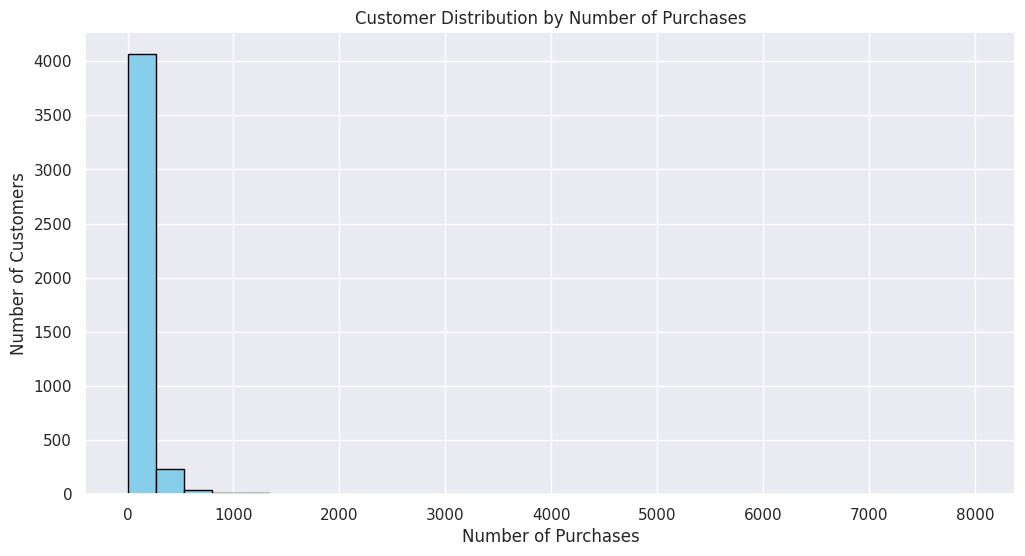

In [ ]:
import matplotlib.pyplot as plt
purchase_counts = df['CustomerID'].value_counts()

plt.figure(figsize=(12,6))
plt.hist(purchase_counts, bins=30, color='skyblue', edgecolor='black')
plt.title('Customer Distribution by Number of Purchases')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()


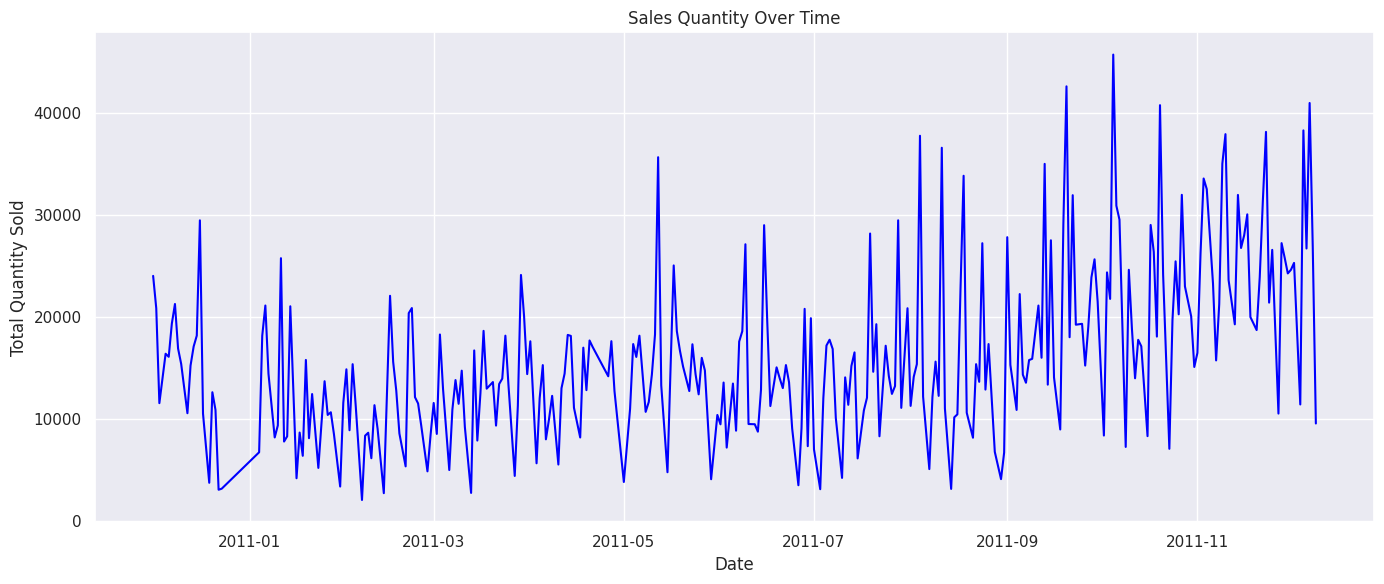

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['Quantity'].sum().reset_index()
daily_sales.columns = ['Date', 'Total_Quantity']
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(daily_sales['Date'], daily_sales['Total_Quantity'], color='blue')
plt.title('Sales Quantity Over Time')
plt.xlabel('Date')
plt.ylabel('Total Quantity Sold')
plt.grid(True)
plt.tight_layout()
plt.show()


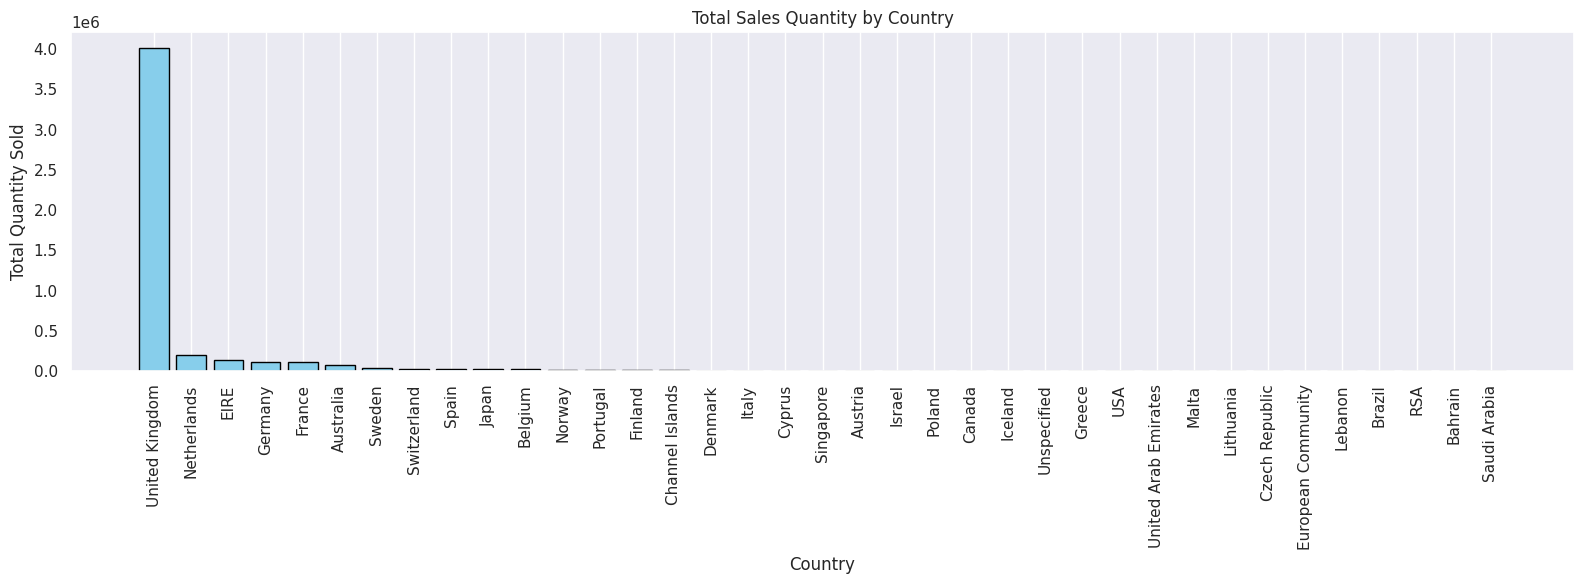

In [ ]:
df = df.dropna(subset=['Country', 'Quantity'])

country_sales = df.groupby('Country')['Quantity'].sum().reset_index()
country_sales = country_sales.sort_values(by='Quantity', ascending=False)
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
plt.bar(country_sales['Country'], country_sales['Quantity'], color='skyblue', edgecolor='black')
plt.title('Total Sales Quantity by Country')
plt.xlabel('Country')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.grid(axis='y')
plt.show()


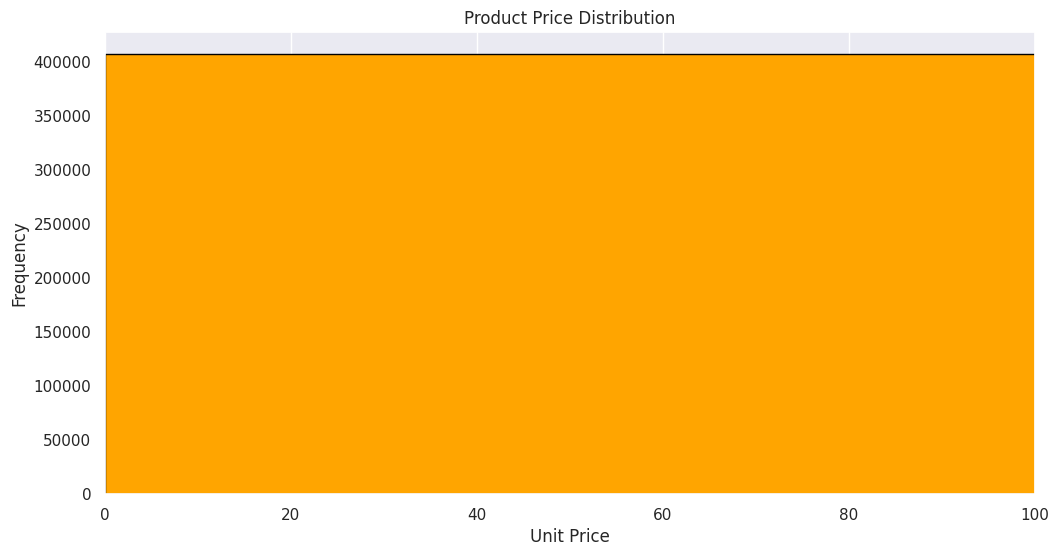

In [ ]:
df = df[df['UnitPrice'] > 0]
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.hist(df['UnitPrice'], bins=100, color='orange', edgecolor='black')
plt.title('Product Price Distribution')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.xlim(0, 100)  # عشان نتجاهل القيم المتطرفة ونركز على الأسعار الواقعية
plt.grid(True)
plt.show()


In [ ]:
df_clean = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] < 1000)]
import plotly.express as px

fig = px.histogram(df_clean, x='UnitPrice',
                   nbins=100,
                   title='Product Price Distribution',
                   labels={'UnitPrice': 'Unit Price'},
                   color_discrete_sequence=['orange'])

fig.update_layout(
    xaxis_range=[0, 100],  # نركز على الأسعار المعقولة فقط
    yaxis_title='Frequency'
)
fig.show()



In [ ]:
df[df['UnitPrice'] > 1000].sort_values(by='UnitPrice', ascending=False).head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,-38970.00
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
173277,C551685,POST,POSTAGE,-1,2011-05-03 12:51:00,8142.75,16029.0,United Kingdom,-8142.75
173391,C551699,M,Manual,-1,2011-05-03 14:12:00,6930.00,16029.0,United Kingdom,-6930.00
268027,C560372,M,Manual,-1,2011-07-18 12:26:00,4287.63,17448.0,United Kingdom,-4287.63
422376,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,12536.0,France,4161.06
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536.0,France,4161.06
422375,C573079,M,Manual,-2,2011-10-27 14:15:00,4161.06,12536.0,France,-8322.12
406406,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,12744.0,Singapore,3949.32
406404,C571750,M,Manual,-1,2011-10-19 11:16:00,3949.32,12744.0,Singapore,-3949.32


In [ ]:
df_clean = df.dropna(subset=['Description', 'Quantity'])
df_clean = df_clean[df_clean['Quantity'] > 0]
product_sales = df_clean.groupby('Description')['Quantity'].sum().reset_index()
product_sales = product_sales.sort_values(by='Quantity', ascending=False)
top_n = 10  # أو أي رقم تحب
top_products = product_sales.head(top_n)
import plotly.express as px

fig = px.bar(top_products,
             x='Description',
             y='Quantity',
             title=f'Top {top_n} Best-Selling Products',
             labels={'Description': 'Product Description', 'Quantity': 'Total Quantity Sold'},
             color='Quantity')

fig.update_layout(xaxis_tickangle=45)
fig.show()


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
monthly_sales = df.groupby('Month')['Quantity'].sum().reset_index()
weekday_sales = df.groupby('DayOfWeek')['Quantity'].sum().reset_index()
from pandas.api.types import CategoricalDtype

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cat_type = CategoricalDtype(categories=day_order, ordered=True)
weekday_sales['DayOfWeek'] = weekday_sales['DayOfWeek'].astype(cat_type)
weekday_sales = weekday_sales.sort_values('DayOfWeek')
import plotly.express as px

fig1 = px.bar(monthly_sales,
              x='Month',
              y='Quantity',
              title='Total Sales Quantity per Month',
              labels={'Month': 'Month', 'Quantity': 'Total Quantity Sold'},
              color='Quantity')
fig1.show()


In [ ]:
fig2 = px.bar(weekday_sales,
              x='DayOfWeek',
              y='Quantity',
              title='Total Sales Quantity per Day of the Week',
              labels={'DayOfWeek': 'Day of Week', 'Quantity': 'Total Quantity Sold'},
              color='Quantity')
fig2.show()


In [ ]:
# تنظيف البيانات
df_clean = df.dropna(subset=['StockCode', 'Quantity'])
df_clean = df_clean[df_clean['Quantity'] > 0]

# تجميع إجمالي الكمية حسب StockCode
stockcode_sales = df_clean.groupby('StockCode')['Quantity'].sum().reset_index()

# ترتيب تنازلي وأخذ أعلى 20 منتج
top_n = 20
top_stockcode_sales = stockcode_sales.sort_values(by='Quantity', ascending=False).head(top_n)
import plotly.express as px

import plotly.express as px

fig = px.bar(top_stockcode_sales,
             x='StockCode',
             y='Quantity',
             title='Top 20 Products by Quantity Sold',
             labels={'StockCode': 'Product StockCode', 'Quantity': 'Total Quantity Sold'},
             color_discrete_sequence=['#1f77b4'])  # ← غير اللون من هنا

# تحكم في الشكل
fig.update_layout(
    width=1000,
    height=500,
    xaxis_tickangle=45,
    bargap=0.0001,  # ↓ كل ما تقلل الرقم ده، الأعمدة تكبر
    plot_bgcolor='black',
)

fig.show()


In [6]:
df['Quantity'].describe()
df[df['Quantity'] < 0]
df[df['UnitPrice'] <= 0]  # أسعار غير منطقية
df[df['UnitPrice'] > 1000]  # أسعار عالية جدًا
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].min(), df['InvoiceDate'].max()
df['CustomerID'].isnull().sum()


np.int64(135080)